In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [2]:
!pip install -q kaggle

In [4]:
import kagglehub

path = kagglehub.dataset_download("awsaf49/mnist-dataset")

print("Path to dataset files:", path)

100%|██████████| 28.6M/28.6M [00:00<00:00, 113MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/mnist-dataset/versions/1


In [5]:
import pandas as pd

train_df = pd.read_csv("/content/sample_data/mnist_train_small.csv")
test_df = pd.read_csv("/content/sample_data/mnist_test.csv")

print("Training Data Shape:", train_df.shape)
print("Testing Data Shape :", test_df.shape)

Training Data Shape: (19999, 785)
Testing Data Shape : (9999, 785)


In [6]:
y_train = train_df.iloc[:, 0]
y_test = test_df.iloc[:, 0]

x_train = train_df.iloc[:, 1:]
x_test = test_df.iloc[:, 1:]

print(x_train.shape)
print(x_test.shape)

(19999, 784)
(9999, 784)


In [7]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [8]:
x_train = x_train.values.reshape(-1, 28, 28, 1)
x_test = x_test.values.reshape(-1, 28, 28, 1)

print(x_train.shape)
print(x_test.shape)

(19999, 28, 28, 1)
(9999, 28, 28, 1)


In [23]:
print("Training Images:", x_train.shape)
print("Testing Images :", x_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Images: (19999, 28, 28, 1)
Testing Images : (9999, 28, 28, 1)
Training Labels: (19999,)
Testing Labels : (9999,)


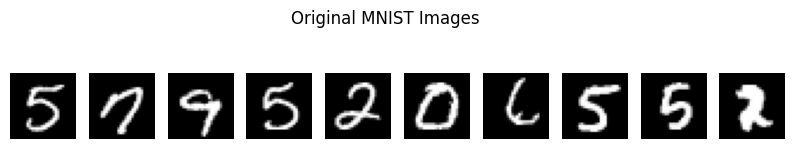

In [9]:
plt.figure(figsize=(10,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.suptitle("Original MNIST Images")
plt.show()

In [10]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

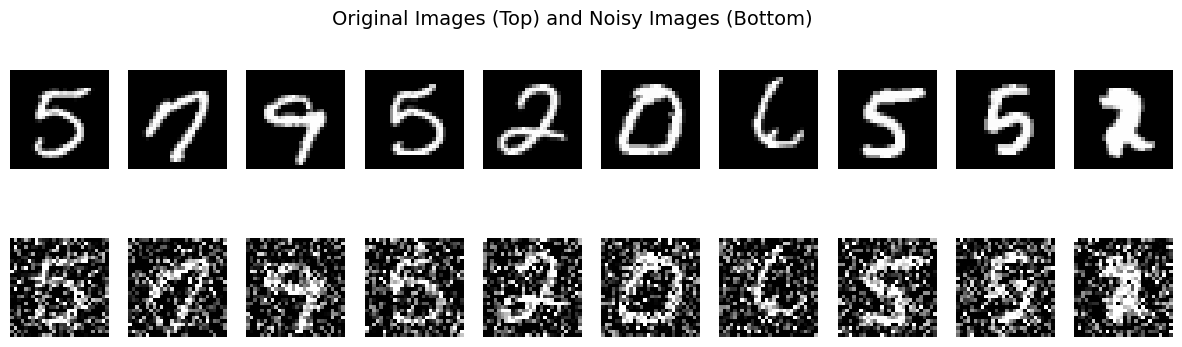

In [11]:
plt.figure(figsize=(15,4))

for i in range(10):

    plt.subplot(2,10,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.axis("off")

    plt.subplot(2,10,i+11)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.suptitle("Original Images (Top) and Noisy Images (Bottom)", fontsize=14)
plt.show()

In [12]:
input_img = Input(shape=(28, 28, 1))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
autoencoder = Model(input_img, decoded)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [18]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1032 - val_loss: 0.1031
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1029 - val_loss: 0.1025
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1027 - val_loss: 0.1019
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1023 - val_loss: 0.1016
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1021 - val_loss: 0.1018
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1018 - val_loss: 0.1013
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1018 - val_loss: 0.1010
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1014 - val_loss: 0.1011
Epoch 9/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1012 - val_loss: 0.1009
Epoch 10/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1011 - val_loss: 0.1014
Epoch 11/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1009 - val_loss: 0.1007
Epoch 12/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

In [19]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


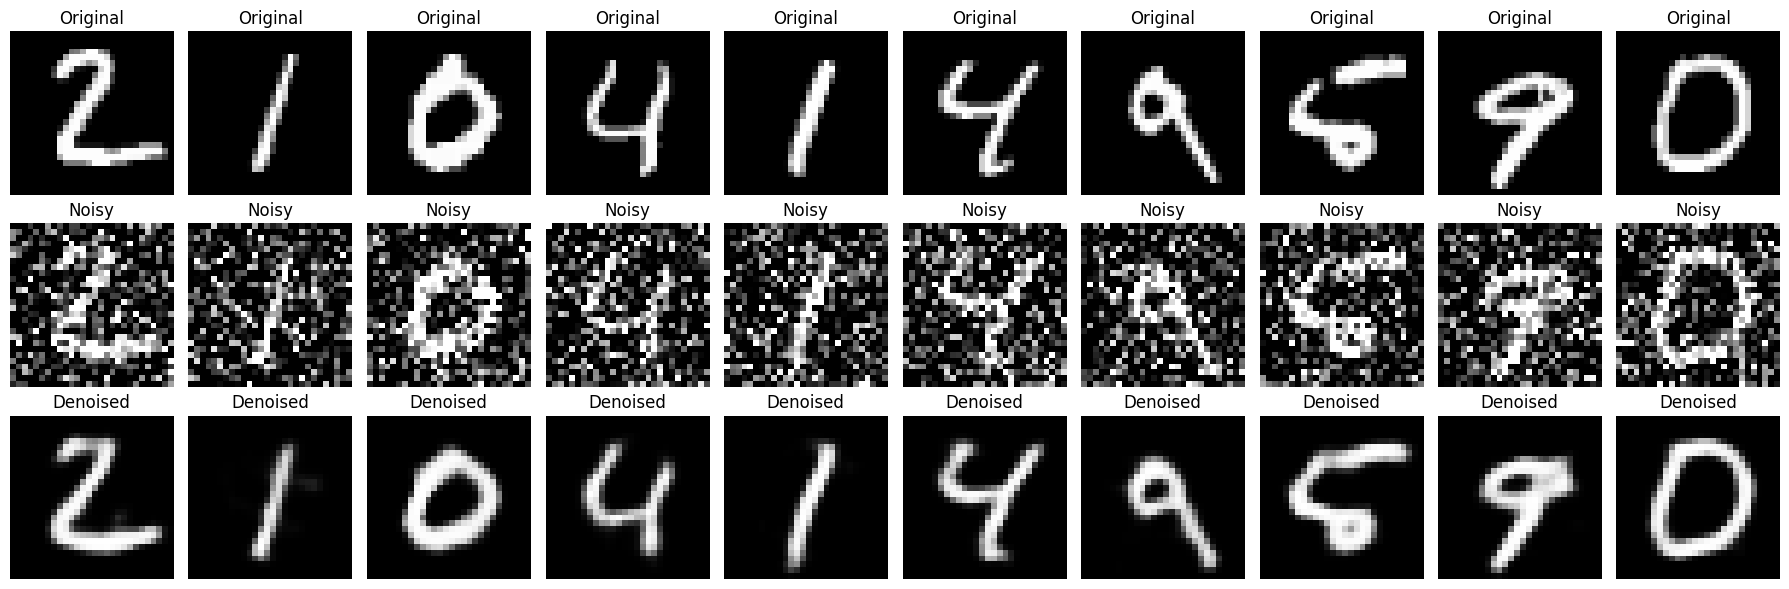

In [20]:
n = 10
plt.figure(figsize=(18,6))
for i in range(n):

    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

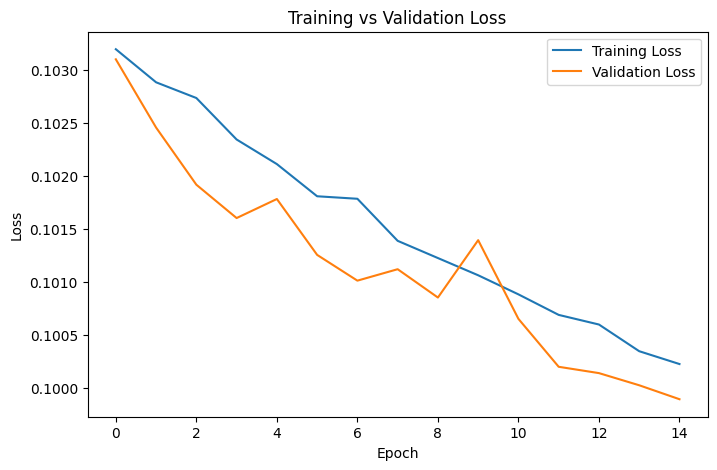

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

## Conclusion

A convolutional denoising autoencoder was developed using the MNIST dataset.
The model successfully reconstructed clean handwritten digit images from noisy inputs.
Training and validation loss decreased consistently, indicating effective learning and good generalization.
The reconstructed images preserved the digit structures while removing most of the Gaussian noise.

## Observations

• Gaussian noise was successfully removed from most images.

• The reconstructed digits closely resembled the original images.

• Digits with simple structures (e.g., 1 and 0) were reconstructed more accurately than more complex digits.

• The model converged within 15 epochs without noticeable overfitting.